# Assignment 01: ML Model for Car Mileage Estimation

## Aim
To predict a car's fuel mileage (MPG) from its technical specifications using supervised regression models.

## Models Used
1. Linear Regression
2. Random Forest Regression

## Evaluation Metrics
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
np.random.seed(42)

n = 500

engine_size = np.random.uniform(1.0, 5.0, n)

horsepower = (
    60
    + engine_size * 40
    + np.random.normal(0, 15, n)
)

weight = (
    900
    + engine_size * 350
    + np.random.normal(0, 100, n)
)

cylinders = np.clip(
    np.round(engine_size * 1.6),
    3,
    12
)

mpg = (
    45
    - engine_size * 4
    - weight * 0.005
    - horsepower * 0.03
    + np.random.normal(0, 1.5, n)
)

mpg = np.clip(mpg, 8, 45)

car_df = pd.DataFrame({
    "engine_size_L": engine_size,
    "horsepower": horsepower,
    "weight_kg": weight,
    "cylinders": cylinders,
    "mpg": mpg
})

car_df.head()

,engine_size_L,horsepower,weight_kg,cylinders,mpg
0,2.498160,165.052759,1832.748985,4.0,22.844642
1,4.802857,280.256852,2545.070820,8.0,8.000000
2,3.927976,231.375388,2333.857002,6.0,10.725556
3,3.394634,187.131803,2198.992236,5.0,13.682422
4,1.624075,111.486762,1550.474315,3.0,28.096686


In [3]:
print("Dataset Shape:", car_df.shape)

print("\nDataset Information:")
print(car_df.info())

print("\nStatistical Summary:")
display(car_df.describe())

Dataset Shape: (500, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   engine_size_L  500 non-null    float64
 1   horsepower     500 non-null    float64
 2   weight_kg      500 non-null    float64
 3   cylinders      500 non-null    float64
 4   mpg            500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB
None

Statistical Summary:


,engine_size_L,horsepower,weight_kg,cylinders,mpg
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.994247,179.884172,1955.257695,4.982000,18.304264
std,1.194754,51.093857,439.253995,1.714513,8.016866
min,1.020246,74.649910,1123.404668,3.000000,8.000000
25%,1.965119,138.259322,1573.257094,3.000000,10.588525
50%,3.052655,181.220620,1974.540625,5.000000,17.570450
75%,4.024500,222.875749,2334.123297,6.000000,25.493698
max,4.971859,285.494329,2868.640153,8.000000,34.148486


In [4]:
X = car_df.drop(columns=["mpg"])
y = car_df["mpg"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,engine_size_L,horsepower,weight_kg,cylinders
0,2.498160,165.052759,1832.748985,4.0
1,4.802857,280.256852,2545.070820,8.0
2,3.927976,231.375388,2333.857002,6.0
3,3.394634,187.131803,2198.992236,5.0
4,1.624075,111.486762,1550.474315,3.0



Target:


,mpg
0,22.844642
1,8.000000
2,10.725556
3,13.682422
4,28.096686


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 400
Testing samples: 100


In [6]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_preds = lr.predict(X_test)

In [7]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_preds = rf.predict(X_test)

In [8]:
results = []

for name, predictions in [
    ("Linear Regression", lr_preds),
    ("Random Forest", rf_preds)
]:

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = mean_squared_error(
        y_test,
        predictions
    ) ** 0.5

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

display(
    results_df.round(3)
)

,Model,MAE,RMSE,R2
0,Linear Regression,1.271,1.568,0.962
1,Random Forest,1.171,1.532,0.963


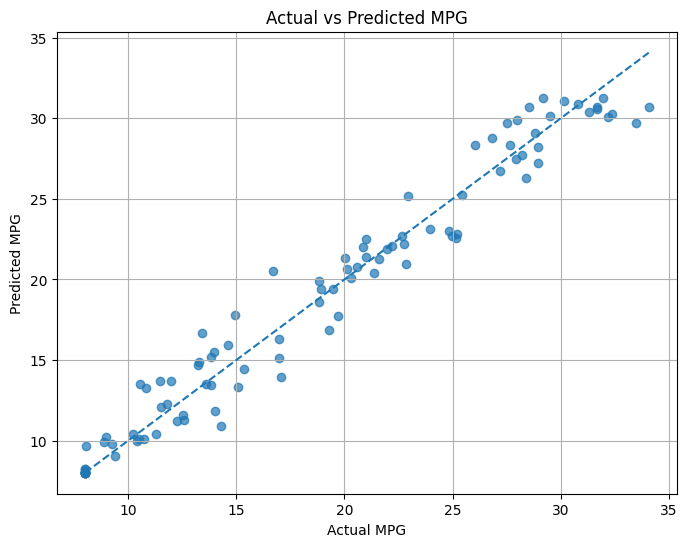

In [9]:
best_predictions = rf_preds

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")

plt.grid(True)
plt.show()

## Result / Conclusion

A regression pipeline was successfully implemented to predict car mileage from technical specifications.

Linear Regression and Random Forest Regression were trained and evaluated using MAE, RMSE and R².

The models were compared on unseen test data, and the Actual vs Predicted MPG plot was used to visually assess prediction performance.